<a href="https://colab.research.google.com/github/davinalifianda123/pengolahan_citra_smt4/blob/main/YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"davinalifiandaadytia","key":"0b5f74a7a2c8ccfd7fd4ac7ebe4bb5fa"}'}

In [2]:
import os

# Pindahkan ke direktori .kaggle
os.makedirs("/root/.kaggle", exist_ok=True)
os.rename("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

In [3]:
import kagglehub

# Download versi terbaru dari dataset
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")

print("Dataset berhasil diunduh ke path:", path)

Dataset berhasil diunduh ke path: /kaggle/input/fashion-product-images-small


In [10]:
# Cell 3: Preprocessing Data Fashion ke Format YOLO
import os
import shutil
import pandas as pd
from tqdm import tqdm

# Path hasil download dari kagglehub
dataset_path = path

# Path gambar dan metadata
image_folder = os.path.join(dataset_path, "images")
metadata_csv = os.path.join(dataset_path, "styles.csv")

# Path output
base_dir = "yolo_fashion_dataset"
images_dir = os.path.join(base_dir, "images")
labels_dir = os.path.join(base_dir, "labels")
os.makedirs(images_dir, exist_ok=True)
os.makedirs(labels_dir, exist_ok=True)

# Baca metadata
df = pd.read_csv(metadata_csv, on_bad_lines='skip')
df = df.dropna(subset=["id", "subCategory"])
df["id"] = df["id"].astype(str)

# Mapping label (subCategory) ke angka
unique_labels = sorted(df["subCategory"].unique())
label2id = {label: idx for idx, label in enumerate(unique_labels)}
id2label = {v: k for k, v in label2id.items()}

print(f"Total kategori unik: {len(unique_labels)}")
print("Contoh kategori:", list(label2id.keys())[:5])

image_count = 0
for _, row in tqdm(df.iterrows(), total=len(df)):
    img_id = row["id"]
    label = row["subCategory"]
    class_id = label2id[label]

    src_path = os.path.join(image_folder, f"{img_id}.jpg")
    if not os.path.exists(src_path):
        continue

    new_filename = f"{img_id}_{label.replace(' ', '_')}"
    dst_img_path = os.path.join(images_dir, f"{new_filename}.png")
    dst_label_path = os.path.join(labels_dir, f"{new_filename}.txt")

    # Salin gambar dan ubah ke PNG jika perlu
    try:
        from PIL import Image
        img = Image.open(src_path).convert("RGB")
        img.save(dst_img_path, format="PNG")
    except Exception as e:
        print(f"❌ Gagal konversi {src_path}: {e}")
        continue

    # Buat file label dengan seluruh gambar sebagai bounding box
    with open(dst_label_path, 'w') as f:
        f.write(f"{class_id} 0.5 0.5 1.0 1.0")

    image_count += 1

print(f"\n✅ Preprocessing selesai. Total {image_count} gambar diproses ke format YOLO.")

# Kumpulkan path file yang akan digunakan untuk K-Fold training di Cell 5
all_image_paths = sorted([os.path.join(images_dir, f) for f in os.listdir(images_dir) if f.endswith(".png")])
all_label_paths = sorted([os.path.join(labels_dir, f) for f in os.listdir(labels_dir) if f.endswith(".txt")])

Total kategori unik: 45
Contoh kategori: ['Accessories', 'Apparel Set', 'Bags', 'Bath and Body', 'Beauty Accessories']


100%|██████████| 44424/44424 [02:08<00:00, 345.38it/s]



✅ Preprocessing selesai. Total 44419 gambar diproses ke format YOLO.


In [11]:
# Cell 4: Menampilkan Kategori Fashion dan Struktur data.yaml
import yaml

# Menampilkan kategori subCategory yang akan digunakan
print("Kategori SubCategory (Fashion) yang akan dilatih:")
for class_id, class_name in id2label.items():
    print(f"ID Kelas: {class_id} -> Nama: {class_name}")

# Contoh struktur data.yaml yang akan kita buat secara dinamis
yaml_structure_info = f"""
# Contoh isi file data.yaml untuk satu fold atau pembagian data:
path: {os.path.abspath(base_dir)}
train: split/train/images
val: split/val/images

nc: {len(id2label)}
names: {list(id2label.values())}
"""

print("\nStruktur file `data.yaml` yang akan dibuat:")
print(yaml_structure_info)

Kategori SubCategory (Fashion) yang akan dilatih:
ID Kelas: 0 -> Nama: Accessories
ID Kelas: 1 -> Nama: Apparel Set
ID Kelas: 2 -> Nama: Bags
ID Kelas: 3 -> Nama: Bath and Body
ID Kelas: 4 -> Nama: Beauty Accessories
ID Kelas: 5 -> Nama: Belts
ID Kelas: 6 -> Nama: Bottomwear
ID Kelas: 7 -> Nama: Cufflinks
ID Kelas: 8 -> Nama: Dress
ID Kelas: 9 -> Nama: Eyes
ID Kelas: 10 -> Nama: Eyewear
ID Kelas: 11 -> Nama: Flip Flops
ID Kelas: 12 -> Nama: Fragrance
ID Kelas: 13 -> Nama: Free Gifts
ID Kelas: 14 -> Nama: Gloves
ID Kelas: 15 -> Nama: Hair
ID Kelas: 16 -> Nama: Headwear
ID Kelas: 17 -> Nama: Home Furnishing
ID Kelas: 18 -> Nama: Innerwear
ID Kelas: 19 -> Nama: Jewellery
ID Kelas: 20 -> Nama: Lips
ID Kelas: 21 -> Nama: Loungewear and Nightwear
ID Kelas: 22 -> Nama: Makeup
ID Kelas: 23 -> Nama: Mufflers
ID Kelas: 24 -> Nama: Nails
ID Kelas: 25 -> Nama: Perfumes
ID Kelas: 26 -> Nama: Sandal
ID Kelas: 27 -> Nama: Saree
ID Kelas: 28 -> Nama: Scarves
ID Kelas: 29 -> Nama: Shoe Accessories
ID K

In [7]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 125.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 105.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstallin

In [12]:
# Cell 5: K-Fold Training untuk YOLO dengan Dataset Fashion
from sklearn.model_selection import KFold
from ultralytics import YOLO
import shutil
import os
import yaml
import numpy as np

# Asumsi: sudah ada dari cell sebelumnya
# base_dir = 'yolo_fashion_dataset'
# id2label = {...}
# all_image_paths, all_label_paths sudah terkumpul di Cell 3

# Konfigurasi K-Fold
N_SPLITS = 5
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

# Konfigurasi Training
EPOCHS = 100
PATIENCE = 5
IMAGE_SIZE = 64

# Simpan hasil setiap fold
fold_training_results = []
best_model_paths = []

# Konversi path ke array numpy
all_image_paths_np = np.array(all_image_paths)
all_label_paths_np = np.array(all_label_paths)

for fold, (train_idx, val_idx) in enumerate(kfold.split(all_image_paths_np)):
    print("-" * 50)
    print(f"Memulai Fold ke-{fold+1}/{N_SPLITS}")
    print("-" * 50)

    # 1. Buat direktori untuk fold ini
    fold_dir = os.path.join(base_dir, f'fold_{fold}')
    fold_images_dir = os.path.join(fold_dir, 'images')
    fold_labels_dir = os.path.join(fold_dir, 'labels')
    fold_train_images_dir = os.path.join(fold_images_dir, 'train')
    fold_train_labels_dir = os.path.join(fold_labels_dir, 'train')
    fold_val_images_dir = os.path.join(fold_images_dir, 'val')
    fold_val_labels_dir = os.path.join(fold_labels_dir, 'val')

    os.makedirs(fold_train_images_dir, exist_ok=True)
    os.makedirs(fold_train_labels_dir, exist_ok=True)
    os.makedirs(fold_val_images_dir, exist_ok=True)
    os.makedirs(fold_val_labels_dir, exist_ok=True)

    # 2. Salin file train dan val
    print("Menyalin file train dan val...")
    for i in train_idx:
        shutil.copy(all_image_paths_np[i], fold_train_images_dir)
        shutil.copy(all_label_paths_np[i], fold_train_labels_dir)
    for i in val_idx:
        shutil.copy(all_image_paths_np[i], fold_val_images_dir)
        shutil.copy(all_label_paths_np[i], fold_val_labels_dir)

    # 3. Buat file data.yaml
    yaml_path = os.path.join(base_dir, f'data_fold_{fold}.yaml')
    yaml_content = {
        'path': os.path.abspath(fold_dir),
        'train': os.path.join('images', 'train'),
        'val': os.path.join('images', 'val'),
        'nc': len(id2label),
        'names': list(id2label.values())
    }
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f, default_flow_style=False)

    # 4. Inisialisasi dan latih model
    model = YOLO('yolov8n.pt')

    print(f"\nMemulai training untuk Fold {fold+1}...")

    training_results = model.train(
        data=yaml_path,
        epochs=EPOCHS,
        patience=PATIENCE,
        imgsz=IMAGE_SIZE,
        project='yolo_fashion_training',
        name=f'fold_{fold}',
        exist_ok=True,
        batch=256
    )

    # 5. Simpan model terbaik dan hasil training
    best_model_path_for_fold = os.path.join(training_results.save_dir, 'weights', 'best.pt')
    best_model_paths.append(best_model_path_for_fold)
    fold_training_results.append(training_results)

    print(f"Training Fold {fold+1} selesai. Model terbaik disimpan di: {best_model_path_for_fold}")

    final_val_map = training_results.results_dict.get('metrics/mAP50-95(B)', None)
    if final_val_map is not None:
        print(f"Final mAP50-95(B) pada validation set untuk Fold {fold+1}: {final_val_map:.4f}")
    else:
        print("⚠️ Tidak ditemukan metrik mAP50-95(B) dari hasil training.")

print("\n✅ Semua proses K-Fold training telah selesai.")

--------------------------------------------------
Memulai Fold ke-1/5
--------------------------------------------------
Menyalin file train dan val...


100%|██████████| 6.25M/6.25M [00:00<00:00, 121MB/s]



Memulai training untuk Fold 1...
Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=256, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo_fashion_dataset/data_fold_0.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=fold_0, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=5, perspect

100%|██████████| 755k/755k [00:00<00:00, 25.4MB/s]

Overriding model.yaml nc=80 with nc=45

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytic

...

                   all       8883       8883      0.737      0.405      0.481        0.4

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


     31/100     0.984G     0.3711     0.6732     0.9142        654         64: 100%|██████████| 139/139 [01:04<00:00,  2.16it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:32<00:00,  1.79s/it]


                   all       8883       8883       0.66      0.451       0.47      0.431
EarlyStopping: Training stopped early as no improvement observed in last 5 epochs. Best results observed at epoch 26, best model saved as best.pt.
To update EarlyStopping(patience=5) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.

31 epochs completed in 0.823 hours.
Optimizer stripped from yolo_fashion_training/fold_4/weights/last.pt, 6.2MB
Optimizer stripped from yolo_fashion_training/fold_4/weights/best.pt, 6.2MB

Validating yolo_fashion_training/fold_4/weights/best.pt...
Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,014,423 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 18/18 [00:36<00:00,  2.05s/it]


                   all       8883       8883      0.819      0.498      0.582      0.575
           Accessories         27         27      0.643      0.704      0.719      0.708
           Apparel Set         16         16      0.169     0.0625      0.331      0.331
                  Bags        598        598      0.839      0.973      0.975      0.942
         Bath and Body          4          4          1          0     0.0777     0.0777
    Beauty Accessories          1          1          0          0          0          0
                 Belts        134        134      0.992      0.948      0.988      0.988
            Bottomwear        554        554      0.664      0.951      0.928       0.92
             Cufflinks         25         25      0.751      0.241      0.505      0.504
                 Dress         88         88      0.643      0.386      0.534      0.527
                  Eyes          7          7          1          0     0.0547     0.0529
               Eyewea

In [13]:
# Cell 6: Menentukan Model Terbaik dari Semua Fold
best_map = -1
overall_best_model_path = None
best_fold_index = -1

print("📊 Hasil mAP50-95(B) dari masing-masing fold:\n")
for i, result in enumerate(fold_training_results):
    current_map = result.results_dict.get('metrics/mAP50-95(B)', None)
    if current_map is not None:
        print(f"Fold {i+1}: mAP50-95(B) = {current_map:.4f}")
        if current_map > best_map:
            best_map = current_map
            overall_best_model_path = best_model_paths[i]
            best_fold_index = i
    else:
        print(f"⚠️ Fold {i+1}: Tidak ditemukan metrik 'mAP50-95(B)'.")

print("-" * 50)
if overall_best_model_path:
    print(f"✅ Model terbaik berasal dari Fold ke-{best_fold_index + 1}")
    print(f"🎯 mAP50-95 tertinggi (validasi): {best_map:.4f}")
    print(f"📁 Path model terbaik: {overall_best_model_path}")
else:
    print("❌ Tidak ada model dengan metrik mAP yang valid ditemukan.")

📊 Hasil mAP50-95(B) dari masing-masing fold:

Fold 1: mAP50-95(B) = 0.4965
Fold 2: mAP50-95(B) = 0.4697
Fold 3: mAP50-95(B) = 0.4255
Fold 4: mAP50-95(B) = 0.4214
Fold 5: mAP50-95(B) = 0.5745
--------------------------------------------------
✅ Model terbaik berasal dari Fold ke-5
🎯 mAP50-95 tertinggi (validasi): 0.5745
📁 Path model terbaik: yolo_fashion_training/fold_4/weights/best.pt


📸 Melakukan prediksi pada 5 gambar fashion...

0: 64x64 1 Shoes, 11.8ms
1: 64x64 1 Jewellery, 1 Lips, 11.8ms
2: 64x64 1 Topwear, 11.8ms
3: 64x64 1 Ties, 11.8ms
4: 64x64 1 Eyewear, 11.8ms
Speed: 0.2ms preprocess, 11.8ms inference, 1.7ms postprocess per image at shape (1, 3, 64, 64)
Results saved to yolo_fashion_predictions/best_model_preds

🖼️ Menampilkan gambar hasil prediksi:


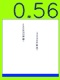

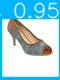

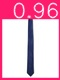

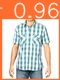

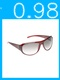

In [14]:
# Cell 7: Prediksi dengan Model Terbaik pada Dataset Fashion
from ultralytics import YOLO
from IPython.display import Image, display
import os
import glob
import random

# Muat model terbaik
best_model = YOLO(overall_best_model_path)

# Ambil 5 gambar acak dari direktori images (tanpa filter nama spesifik)
test_image_paths = random.sample(glob.glob(os.path.join(images_dir, '*.png')), k=5)

if not test_image_paths:
    print("❌ Tidak ditemukan gambar PNG di direktori images.")
else:
    print(f"📸 Melakukan prediksi pada {len(test_image_paths)} gambar fashion...")
    results = best_model.predict(
        source=test_image_paths,
        save=True,
        project='yolo_fashion_predictions',
        name='best_model_preds',
        exist_ok=True
    )

    # Ambil path hasil prediksi dari direktori simpanan
    prediction_dir = results[0].save_dir
    predicted_images = glob.glob(os.path.join(prediction_dir, '*.jpg'))

    if not predicted_images:
        print("❌ Tidak ada gambar hasil prediksi yang ditemukan.")
    else:
        print("\n🖼️ Menampilkan gambar hasil prediksi:")
        for img_path in predicted_images:
            display(Image(filename=img_path, width=400))

📈 Menampilkan grafik training dari Fold ke-5


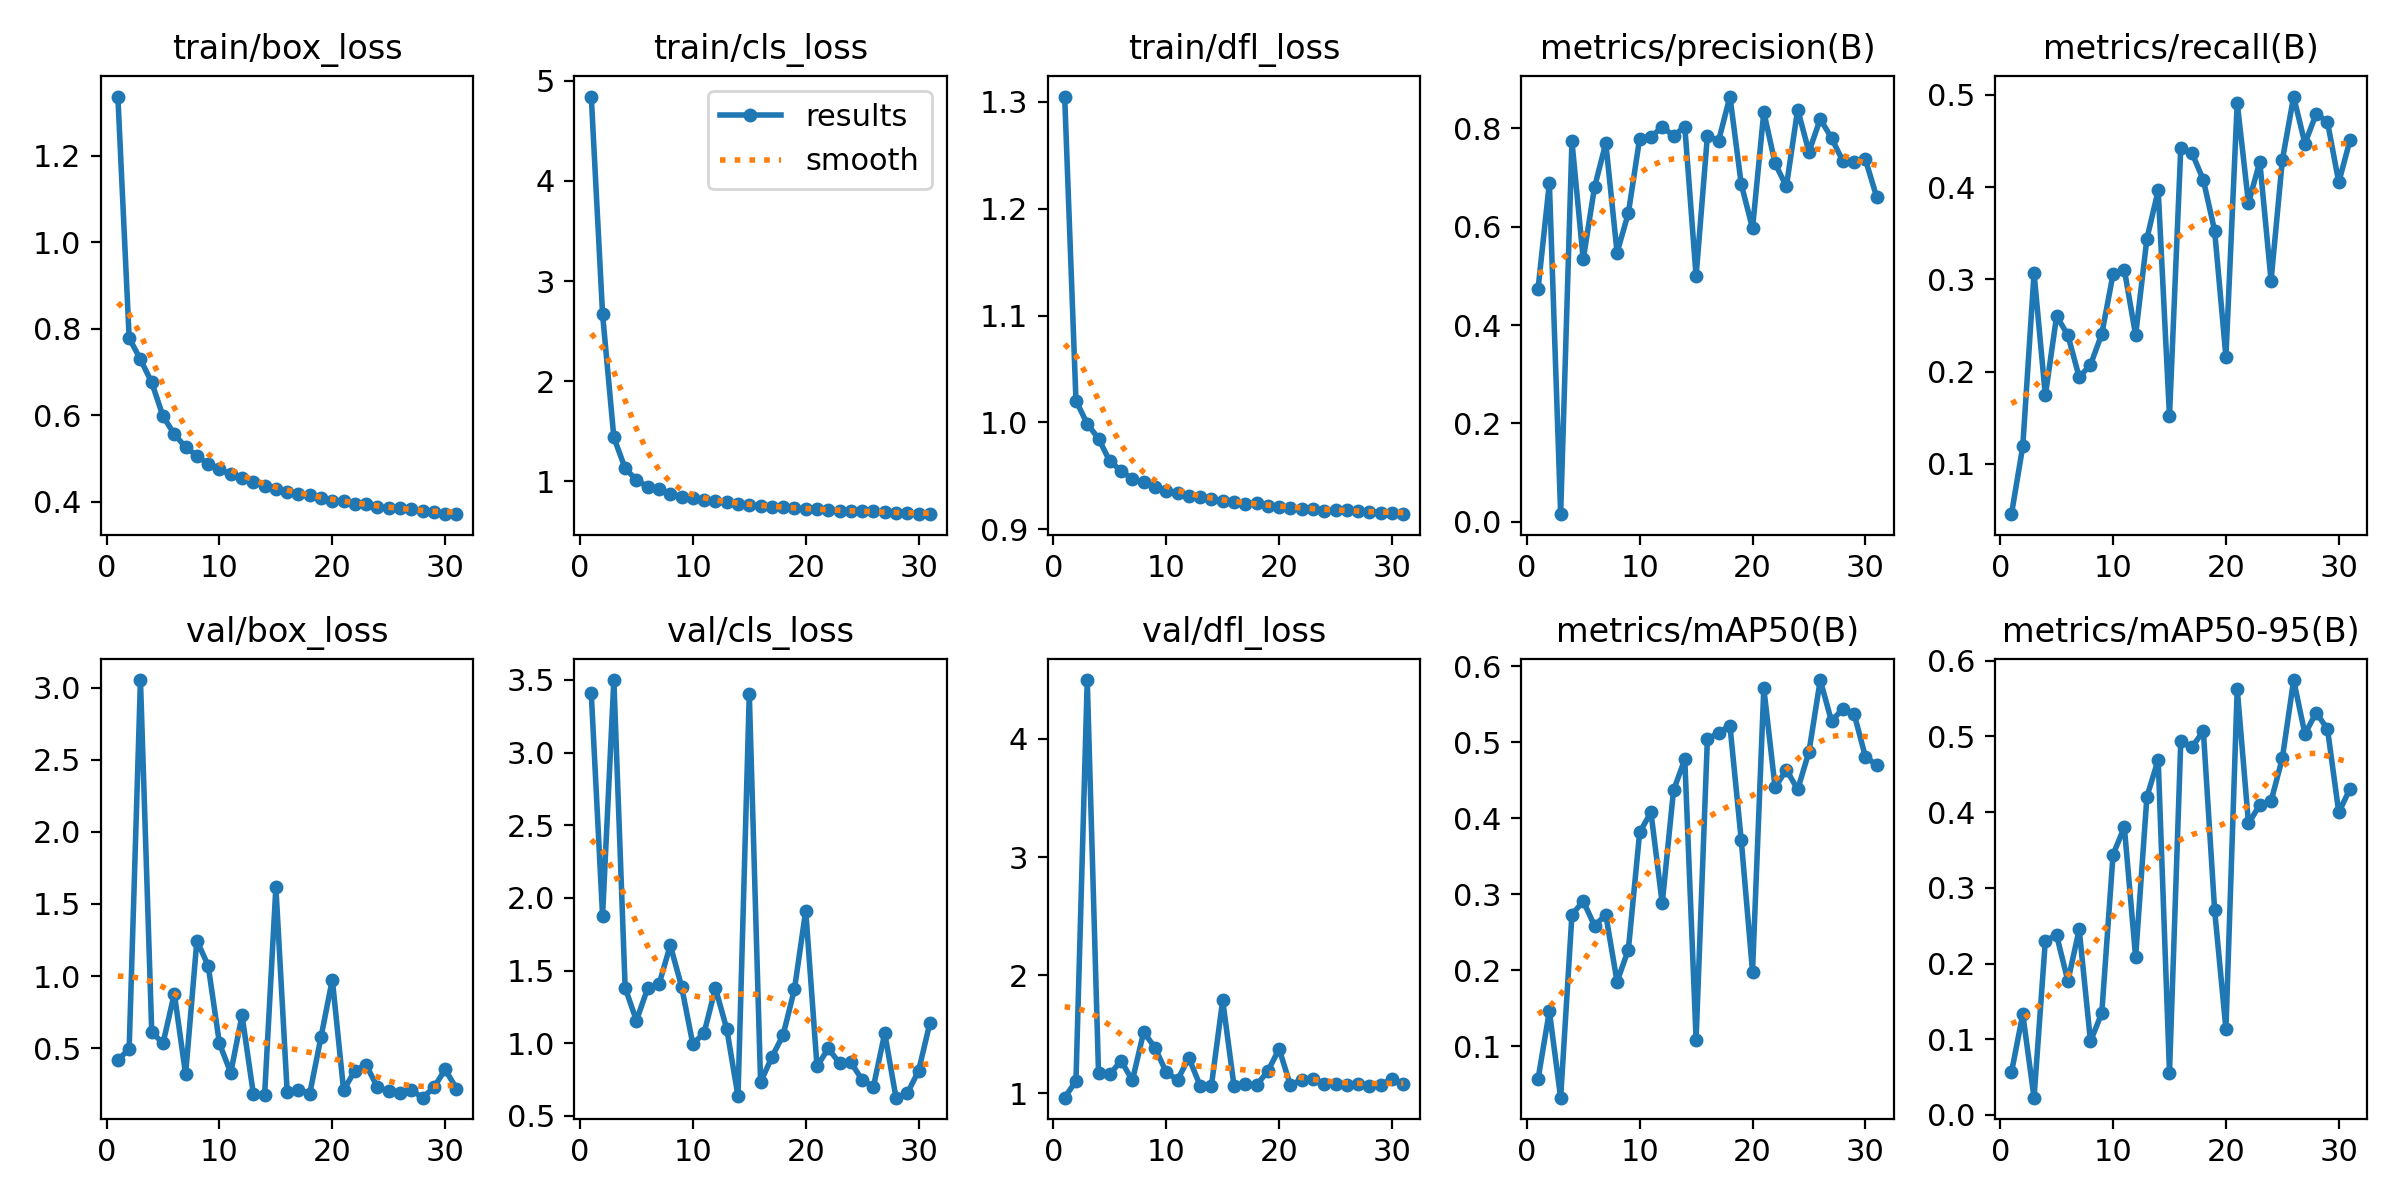

In [15]:
# Cell 8: Menampilkan Grafik Hasil Training dari Fold Terbaik
from IPython.display import Image, display
import os

# Path ke direktori hasil training dari fold terbaik
best_fold_run_dir = os.path.join('yolo_fashion_training', f'fold_{best_fold_index}')

# Path ke file grafik hasil training
results_chart_path = os.path.join(best_fold_run_dir, 'results.png')

# Tampilkan grafik jika tersedia
if os.path.exists(results_chart_path):
    print(f"📈 Menampilkan grafik training dari Fold ke-{best_fold_index + 1}")
    display(Image(filename=results_chart_path))
else:
    print("❌ File 'results.png' tidak ditemukan di direktori training yang dipilih.")

📁 Menyalin 2220 gambar ke direktori test...


Copying images: 100%|██████████| 2220/2220 [00:00<00:00, 3546.72it/s]


✅ Setup untuk evaluasi pada Test Set selesai.

🔍 Mengevaluasi model terbaik pada Test Set...
Ultralytics 8.3.160 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)


Model summary (fused): 72 layers, 3,014,423 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 223.7±112.6 MB/s, size: 5.2 KB)


val: Scanning /content/yolo_fashion_dataset/test/labels... 2220 images, 0 backgrounds, 0 corrupt: 100%|██████████| 2220/2220 [00:00<00:00, 2638.74it/s]

val: New cache created: /content/yolo_fashion_dataset/test/labels.cache



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 139/139 [00:19<00:00,  7.22it/s]


                   all       2220       2220      0.783      0.607       0.68      0.672
           Accessories          4          4      0.548        0.5      0.512      0.508
           Apparel Set          5          5      0.629      0.688      0.711      0.711
                  Bags        170        170      0.815      0.982       0.98      0.962
         Bath and Body          1          1          1          0      0.249      0.249
                 Belts         35         35      0.946      0.992      0.992      0.992
            Bottomwear        140        140       0.61       0.94      0.946       0.94
             Cufflinks          5          5      0.821          1      0.895      0.895
                 Dress         27         27      0.504      0.296      0.554      0.526
                  Eyes          1          1          1          0     0.0153     0.0153
               Eyewear         53         53       0.95          1       0.99       0.99
            Flip Flop

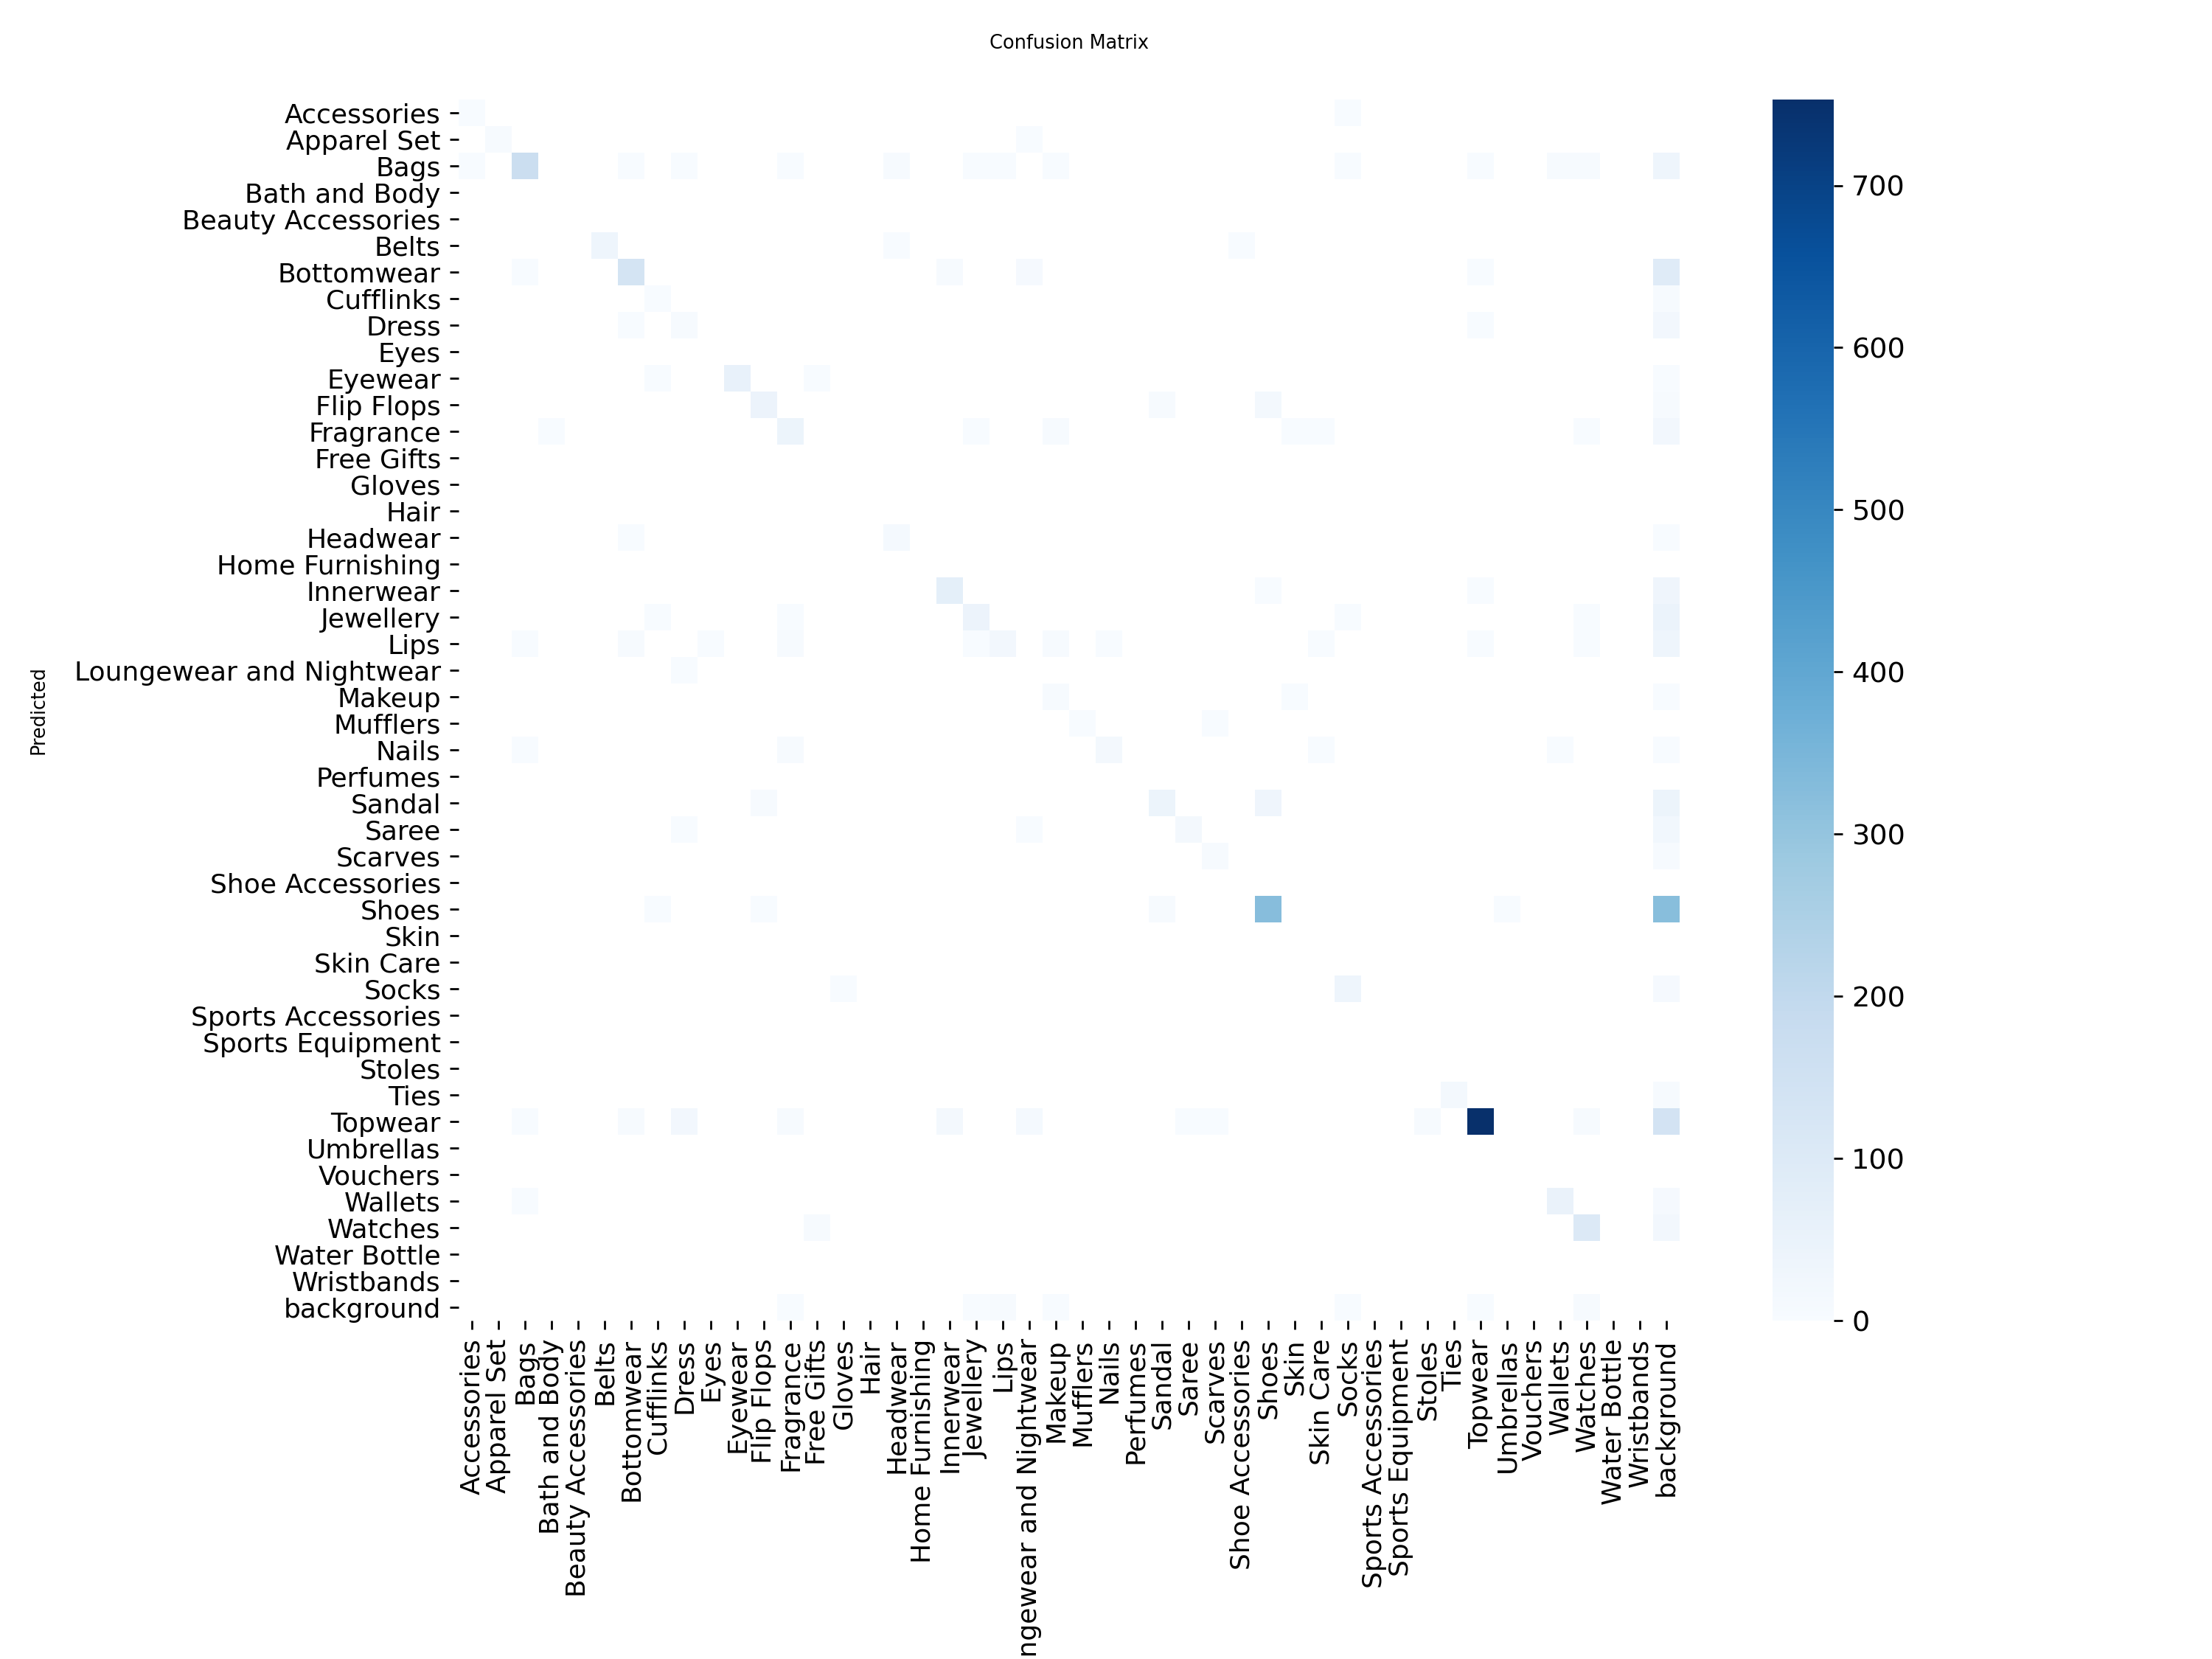

In [16]:
# Cell 9: Membuat Direktori, YAML, dan Mengevaluasi pada Test Set
import os
import shutil
import glob
import yaml
import numpy as np
from ultralytics import YOLO
from tqdm import tqdm
from IPython.display import display, Image
import random

# Asumsi: variabel berikut sudah tersedia dari cell sebelumnya
# base_dir, images_dir, labels_dir, id2label, overall_best_model_path

# 1. Buat direktori untuk test set (ambil subset dari dataset utama)
test_images_dir = os.path.join(base_dir, 'test', 'images')
test_labels_dir = os.path.join(base_dir, 'test', 'labels')
os.makedirs(test_images_dir, exist_ok=True)
os.makedirs(test_labels_dir, exist_ok=True)

# 2. Ambil subset acak untuk test (misal 5% dari seluruh data)
num_test_samples = max(100, int(0.05 * len(all_image_paths)))  # Minimal 100 sample
test_indices = random.sample(range(len(all_image_paths)), num_test_samples)

print(f"📁 Menyalin {num_test_samples} gambar ke direktori test...")

for i in tqdm(test_indices, desc="Copying images"):
    shutil.copy(all_image_paths[i], test_images_dir)
    shutil.copy(all_label_paths[i], test_labels_dir)

# 3. Buat file test.yaml
test_yaml_path = os.path.join(base_dir, 'test.yaml')
test_yaml_content = {
    'path': os.path.abspath(base_dir),
    'train': '',  # Tidak digunakan
    'val': '',    # Tidak digunakan
    'test': os.path.join('test', 'images'),
    'nc': len(id2label),
    'names': list(id2label.values())
}
with open(test_yaml_path, 'w') as f:
    yaml.dump(test_yaml_content, f, default_flow_style=False)

print("\n✅ Setup untuk evaluasi pada Test Set selesai.")

# ==============================================================================
# --- EVALUASI MODEL ---
# ==============================================================================
print("\n🔍 Mengevaluasi model terbaik pada Test Set...")
best_model = YOLO(overall_best_model_path)
metrics = best_model.val(
    data=test_yaml_path,
    split='test',
    project='yolo_fashion_evaluation',
    name='final_test_metrics',
    save_conf=True,
    save_json=True
)

# ==============================================================================
# --- METRIK DAN CONFUSION MATRIX ---
# ==============================================================================
print("\n" + "="*50)
print("📊 HASIL EVALUASI PADA TEST SET")
print("="*50)

# 1. Metrik deteksi
box_metrics = metrics.box
print(f"🎯 Presisi (Precision)     : {box_metrics.p[0]:.4f}")
print(f"🔁 Recall                 : {box_metrics.r[0]:.4f}")
print(f"📦 mAP50                  : {box_metrics.map50:.4f}")
print(f"📦 mAP50-95               : {box_metrics.map:.4f}")
print("-" * 50)

# 2. Akurasi berdasarkan Confusion Matrix
cm_data = metrics.confusion_matrix.matrix
correct_predictions = np.trace(cm_data)
total_predictions = np.sum(cm_data)

if total_predictions > 0:
    accuracy = correct_predictions / total_predictions
    print(f"✅ Akurasi: {accuracy:.4f} ({int(correct_predictions)}/{int(total_predictions)} benar)")
else:
    print("⚠️ Tidak ada prediksi untuk dihitung.")

print("="*50 + "\n")

# 3. Tampilkan confusion matrix
confusion_matrix_path = metrics.save_dir / 'confusion_matrix.png'
if os.path.exists(confusion_matrix_path):
    print("🧩 Confusion Matrix pada Test Set:")
    display(Image(filename=confusion_matrix_path, width=800))
else:
    print("⚠️ File 'confusion_matrix.png' tidak ditemukan.")